# Проект

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import random

import optuna
import shap
import mlflow

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.impute import IterativeImputer
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from darts import TimeSeries
from darts.metrics import wmape

import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = None
sklearn.set_config(transform_output='pandas')
pd.set_option('display.max_columns', None)

np.random.seed(42)
random.seed(42)

c:\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("rossmann_sales_forecast_v1")

2026/07/26 21:53:45 INFO mlflow.tracking.fluent: Experiment with name 'rossmann_sales_forecast_v1' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1785092024594, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1785092024594, lifecycle_stage='active', name='rossmann_sales_forecast_v1', tags={}, trace_location=None, workspace='default'>

# Достаем данные

In [3]:
path = kagglehub.dataset_download("shahpranshu27/rossman-store-sales")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\arutg\.cache\kagglehub\datasets\shahpranshu27\rossman-store-sales\versions\1


In [4]:
train = pd.read_csv(path + '/rossmann-store-sales/train.csv', low_memory=False, parse_dates=['Date'])
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store = pd.read_csv(path + '/rossmann-store-sales/store.csv', low_memory=False)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
store[['Promo2SinceWeek', 'Promo2SinceYear']] = store[['Promo2SinceWeek', 'Promo2SinceYear']].fillna(0)

In [7]:
cat_features = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'DayOfWeek']

## Объединим train и store в один датафрейм для обучения

In [8]:
df = train.merge(store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NaN


In [9]:
df = df.sort_values(by='Date').reset_index(drop=True)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1,379,2,2013-01-01,0,0,0,0,a,1,d,a,6630.0,NaN,NaN,0,0.0,0.0,NaN
2,378,2,2013-01-01,0,0,0,0,a,1,a,c,2140.0,8.0,2012.0,0,0.0,0.0,NaN
3,377,2,2013-01-01,0,0,0,0,a,1,a,c,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov"
4,376,2,2013-01-01,0,0,0,0,a,1,a,a,160.0,8.0,2012.0,0,0.0,0.0,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

# EDA

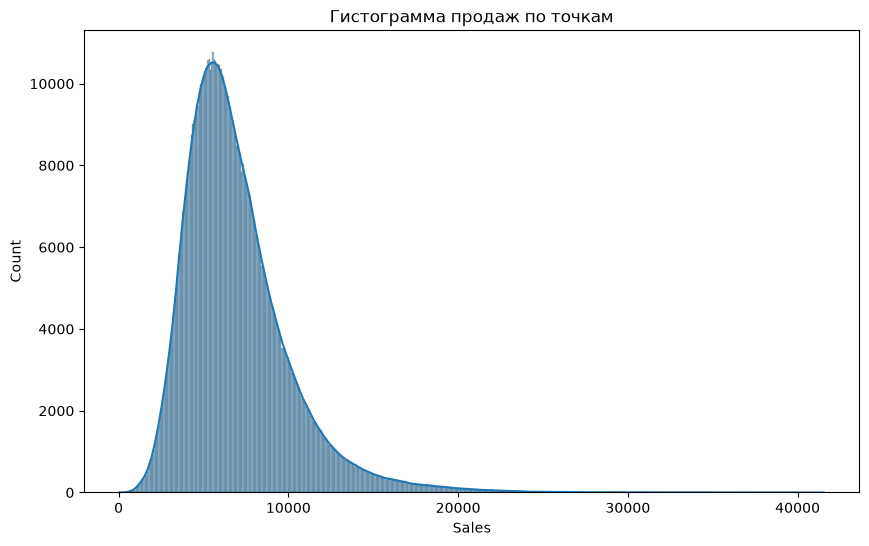

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df[df['Sales'] > 0], x='Sales', kde=True, ax=ax)
ax.set_title('Гистограмма продаж по точкам')
plt.show()

В основном за день один магазин зарабатывает около 8к евро

In [12]:
print(f"Коэф. ассиметрии = {df[df['Sales'] > 0]['Sales'].skew().item():.3f}. Пик смещен влево")
print(f"Коэф. эксцесса = {df[df['Sales'] > 0]['Sales'].kurt().item():.3f}. Пик острый")

Коэф. ассиметрии = 1.595. Пик смещен влево
Коэф. эксцесса = 4.854. Пик острый


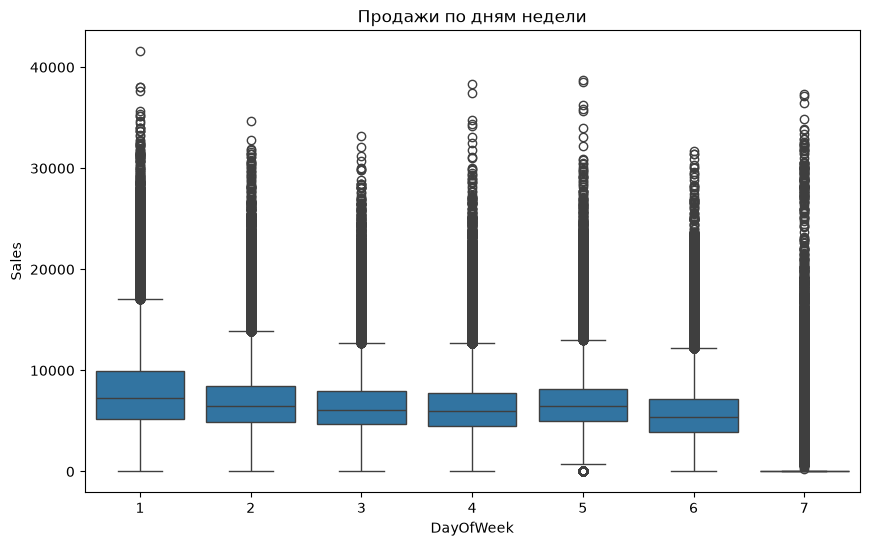

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='DayOfWeek', y='Sales', ax=ax)
ax.set_title('Продажи по дням недели')
plt.show()

Основная доля продаж приходится на воскресенье и понедельник

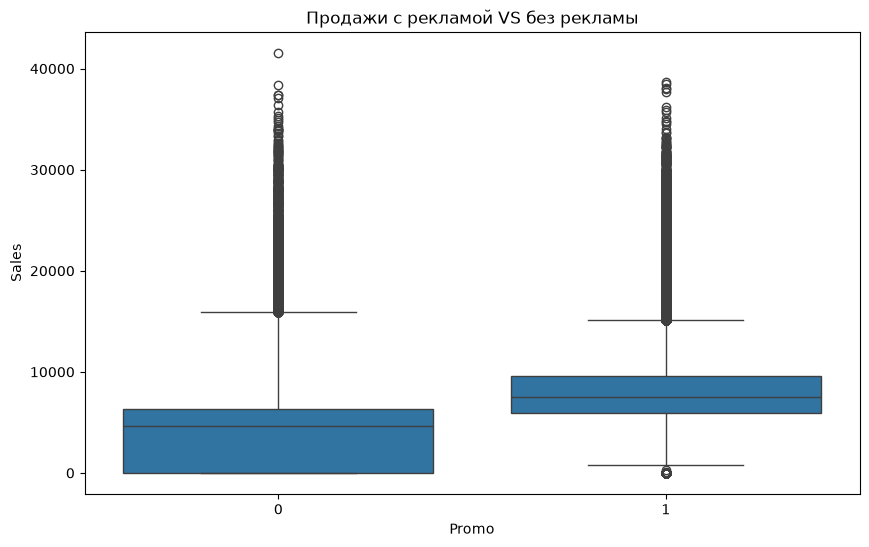

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Promo', y='Sales', ax=ax)
ax.set_title('Продажи с рекламой VS без рекламы')
plt.show()

Реклама позитивно влияет на продажи

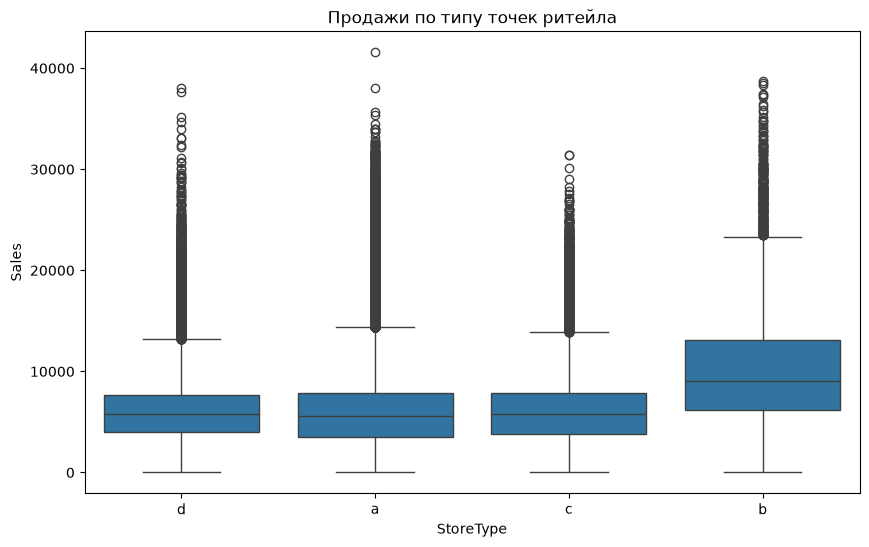

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='StoreType', y='Sales', ax=ax)
ax.set_title('Продажи по типу точек ритейла')
plt.show()

Точки ритейла типа b лучше всего продаются

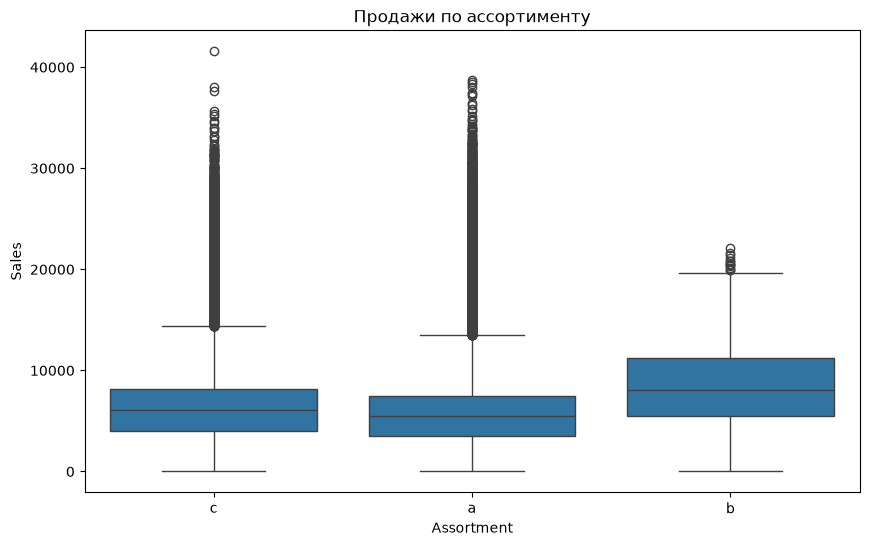

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Assortment', y='Sales', ax=ax)
ax.set_title('Продажи по ассортименту')
plt.show()

Ассортимент b лучше всего продается

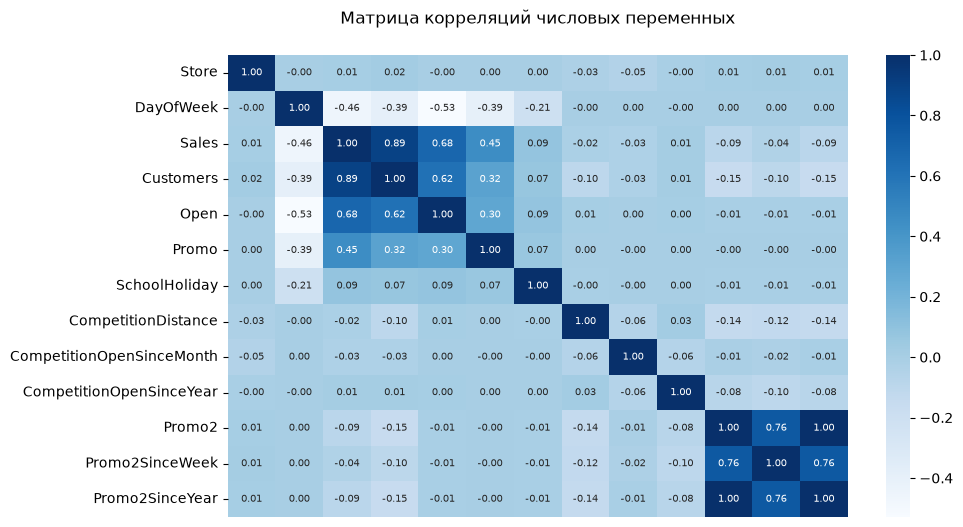

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={"size": 7},
    xticklabels=False,
    ax=ax
)
ax.set_title('Матрица корреляций числовых переменных', y=1.05)
plt.show()

Видно, что Customers и Promo сильно коррелируют с таргетом

# Feature Engineering

## Фичи по дате

In [18]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfMonth'] = df['Date'].dt.day
df['DayOfYear'] = df['Date'].dt.day_of_year

## Фичи по конкурентам
Сколько месяцев на текущий момент функционирует конкурент. От текущей даты вычитаем дату открытия и переводим в месяцы

In [19]:
competitors_dates = {
    'year': df['CompetitionOpenSinceYear'],
    'month': df['CompetitionOpenSinceMonth'],
    'day': 1
}

df_dates = pd.to_datetime(competitors_dates)
diff = (df['Date'].dt.to_period('M') - df_dates.dt.to_period('M')).apply(lambda x: x.n if pd.notna(x) else np.nan)

df['CompetitionMonths'] = diff
df = df.drop(columns=['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'])

## Бинарная фича из PromoIntertest

In [20]:
months_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10,
'Nov': 11, 'Dec': 12}

def func_filter(row):
    if isinstance(row, list):
        return [months_mapping[x] for x in row]
    else:
        return [0]

In [21]:
df['PromoInterval'] = df['PromoInterval'].str.split(',').apply(func_filter)

In [22]:
df['Promo2Exists'] = df.apply(lambda row: row['Month'] in row['PromoInterval'], axis=1)

In [23]:
mask = df['Promo2'] == 1
years = df[mask]['Promo2SinceYear'].astype(int).astype(str)
weeks = df[mask]['Promo2SinceWeek'].astype(int).astype(str)
date_strings = years + '-' + weeks + '-1'

df.loc[mask, 'Promo2StartDate'] = pd.to_datetime(date_strings, format='%Y-%W-%w')

In [24]:
df['IsPromo2Month'] = (df['Promo2']) & (df['Date'] >= df['Promo2StartDate']) & (df['Promo2Exists'])

In [25]:
df = df.drop(columns=['PromoInterval', 'Promo2Exists', 'Promo2StartDate'])

## Скользящие характеристики

In [26]:
df['PromoMean7'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=7).mean())
df['PromoMean28'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=28).mean())

In [27]:
df['SchoolHolidaySum7'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=7).sum())
df['SchoolHolidaySum28'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=28).sum())

## Типы данных

In [28]:
df['StoreType'] = df['StoreType'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4})
df['Assortment'] = df['Assortment'].map({'a': 1, 'b': 2, 'c': 3})
df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3})
df = df.drop(columns=['Customers'])

# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [29]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [30]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Пропуски в данных

In [31]:
missing = train_df.isna().sum()
missing[missing > 0]

CompetitionDistance      2234
CompetitionMonths      275204
PromoMean7               7805
PromoMean28             31220
SchoolHolidaySum7        7805
SchoolHolidaySum28      31220
dtype: int64

## Анализ кластеров NaN

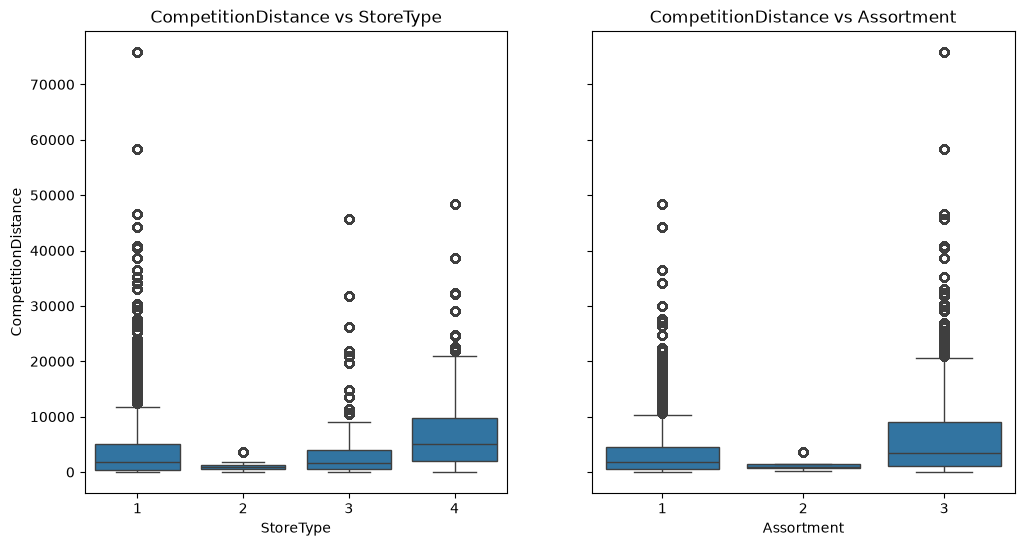

In [32]:
no_competitors = train_df[pd.notna(train_df['CompetitionDistance'])]
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))

sns.boxplot(no_competitors, x='StoreType', y='CompetitionDistance', ax=ax[0])
ax[0].set_title("CompetitionDistance vs StoreType")

sns.boxplot(no_competitors, x='Assortment', y='CompetitionDistance', ax=ax[1])
ax[1].set_title("CompetitionDistance vs Assortment")

plt.show()

In [33]:
train_clusters = train_df.copy()
group_medians = train_clusters.groupby(['StoreType', 'Assortment'])[['CompetitionDistance', 'CompetitionMonths']].transform('median')
global_medians = train_clusters[['CompetitionMonths']].median()

In [34]:
train_clusters[['CompetitionDistance', 'CompetitionMonths']] = train_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
train_clusters[['CompetitionMonths']] = train_clusters[['CompetitionMonths']].fillna(global_medians)

In [35]:
val_clusters = val_df.copy()
val_clusters[['CompetitionDistance', 'CompetitionMonths']] = val_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
val_clusters[['CompetitionMonths']] = val_clusters[['CompetitionMonths']].fillna(global_medians)

In [36]:
X_train, y_train = train_clusters.drop(columns=['Sales', 'Date']), train_clusters['Sales']
X_val, y_val = val_clusters.drop(columns=['Sales', 'Date']), val_clusters['Sales']

In [37]:
mlflow.start_run(run_name='impute_group_median')

<ActiveRun: >

In [38]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [39]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9314111480082972
MSE score = 1069643.593041187
RMSE score = 1034.2357531245896
WAPE score = 11.388225715533563


In [40]:
mlflow.log_param('imputer', 'group_median_fillna')
mlflow.log_metric('R2', r2)
mlflow.log_metric('MSE', mse)
mlflow.log_metric('RMSE', rmse)
mlflow.log_metric('WAPE', wape)
mlflow.end_run()

🏃 View run impute_group_median at: http://localhost:5000/#/experiments/2/runs/b458052ed1ab44d0aa7166f6967d8e2b
🧪 View experiment at: http://localhost:5000/#/experiments/2


## IterativeImputer / BayesianRidge

In [41]:
mlflow.start_run(run_name='impute_iterative_bayesian_ridge')

<ActiveRun: >

In [42]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

In [44]:
br_impute = IterativeImputer(random_state=42)
X_train_br = pd.DataFrame(scaler.inverse_transform(br_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_br = pd.DataFrame(scaler.inverse_transform(br_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

In [45]:
X_train_br['CompetitionMonths'] = X_train_br['CompetitionMonths'].astype(int)
X_train_br['SchoolHolidaySum7'] = X_train_br['SchoolHolidaySum7'].astype(int)
X_train_br['SchoolHolidaySum28'] = X_train_br['SchoolHolidaySum28'].astype(int)

X_val_br['CompetitionMonths'] = X_val_br['CompetitionMonths'].astype(int)
X_val_br['SchoolHolidaySum7'] = X_val_br['SchoolHolidaySum7'].astype(int)
X_val_br['SchoolHolidaySum28'] = X_val_br['SchoolHolidaySum28'].astype(int)

In [46]:
X_train = train_df[cat_features + bool_features].join(X_train_br).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_br).reindex(columns=target_columns)
y_val = val_df['Sales']

In [47]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [48]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9308376742768921
MSE score = 1078586.9196133974
RMSE score = 1038.5503933913835
WAPE score = 11.454827009716096


In [49]:
mlflow.log_param('imputer', 'iterative_bayesian_ridge')
mlflow.log_metric('R2', r2)
mlflow.log_metric('MSE', mse)
mlflow.log_metric('RMSE', rmse)
mlflow.log_metric('WAPE', wape)
mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
mlflow.sklearn.log_model(br_impute, 'imputer', serialization_format='pickle')
mlflow.end_run()

2026/07/26 21:55:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 21:55:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 21:55:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 21:55:51 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/26 21:55:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 21:55:51 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run impute_iterative_bayesian_ridge at: http://localhost:5000/#/experiments/2/runs/5d00dece9d8b4007b0bc732e54941934
🧪 View experiment at: http://localhost:5000/#/experiments/2


## IterativeImputer / SVR

In [50]:
mlflow.start_run(run_name='impute_iterative_svr')

<ActiveRun: >

In [51]:
svr_impute = IterativeImputer(estimator=SVR(max_iter=500, cache_size=1000), max_iter=5, random_state=42)
X_train_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

In [52]:
X_train_svr['CompetitionMonths'] = X_train_svr['CompetitionMonths'].astype(int)
X_train_svr['SchoolHolidaySum7'] = X_train_svr['SchoolHolidaySum7'].astype(int)
X_train_svr['SchoolHolidaySum28'] = X_train_svr['SchoolHolidaySum28'].astype(int)

X_val_svr['CompetitionMonths'] = X_val_svr['CompetitionMonths'].astype(int)
X_val_svr['SchoolHolidaySum7'] = X_val_svr['SchoolHolidaySum7'].astype(int)
X_val_svr['SchoolHolidaySum28'] = X_val_svr['SchoolHolidaySum28'].astype(int)

In [53]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [54]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [55]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9307539126586122
MSE score = 1079893.1825954174
RMSE score = 1039.179090722777
WAPE score = 11.374687364867041


In [56]:
mlflow.log_param('imputer', 'iterative_svr')
mlflow.log_metric('R2', r2)
mlflow.log_metric('MSE', mse)
mlflow.log_metric('RMSE', rmse)
mlflow.log_metric('WAPE', wape)
mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
mlflow.sklearn.log_model(svr_impute, 'imputer', serialization_format='pickle')
mlflow.end_run()

2026/07/26 22:52:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 22:52:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 22:52:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 22:52:56 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/26 22:52:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 22:52:56 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run impute_iterative_svr at: http://localhost:5000/#/experiments/2/runs/1af4a911527e404a97cd0be0bc9f50ff
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Выбор лучшего Imputer

In [57]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

In [58]:
X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [59]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [60]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

# Обучение

In [61]:
def get_period_config(n_weeks: int) -> dict:
    PERIOD_CONFIG = {
        1:  {'lags': [1, 2, 3, 4], 'windows': [4, 12], 'pct_change': [4, 12]},
        2:  {'lags': [1, 2, 3],    'windows': [2, 6],  'pct_change': [2, 6]},
        4:  {'lags': [1, 2, 3],    'windows': [3, 6],  'pct_change': [1, 3]},
        6:  {'lags': [1, 2],       'windows': [2, 4],  'pct_change': [1, 2]},
        12: {'lags': [1, 2],       'windows': [2, 3],  'pct_change': [1, 2]},
    }

    return PERIOD_CONFIG[n_weeks]

In [62]:
def add_target_features(data: pd.DataFrame, n_weeks: int) -> pd.DataFrame:
    data = data.sort_values(['Store', 'Date'])
    cfg = get_period_config(n_weeks)

    for lag in cfg['lags']:
        data[f'SalesLag{lag}'] = data.groupby('Store')['Sales'].shift(lag)

    for window in cfg['windows']:
        data[f'SalesMean{window}'] = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).mean())
        data[f'SalesStd{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).std())
        data[f'SalesMin{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).min())
        data[f'SalesMax{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).max())

    for periods in cfg['pct_change']:
        weeks_back = periods * n_weeks
        data[f'SalesPctChange{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.pct_change(periods).replace(np.inf, np.nan)
        )
        data[f'SalesDiff{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.diff(periods)
        )

    return data

In [63]:
def get_target_feature_cols(n_weeks: int) -> list[str]:
    cfg = get_period_config(n_weeks)
    cols = [f'SalesLag{lag}' for lag in cfg['lags']]
    for w in cfg['windows']:
        cols += [f'SalesMean{w}', f'SalesStd{w}', f'SalesMin{w}', f'SalesMax{w}']
    for periods in cfg['pct_change']:
        cols += [f'SalesPctChange{periods * n_weeks}w', f'SalesDiff{periods * n_weeks}w']
    return cols

In [64]:
def aggregate_bucket(full_df: pd.DataFrame, n_weeks: int, agg_dict: dict) -> pd.DataFrame:
    tmp = full_df.copy()
    tmp['WeekNum'] = tmp['Week'].rank(method='dense').astype(int) - 1
    tmp['Bucket'] = tmp['WeekNum'] // n_weeks
    tmp = tmp.drop(columns=['WeekNum'])

    bucket_df = tmp.groupby(['Store', 'Bucket']).agg(agg_dict)
    bucket_df['n_days'] = tmp.groupby(['Store', 'Bucket'])['Date'].count()
    bucket_df = bucket_df[bucket_df['n_days'] == n_weeks * 7]
    bucket_df = bucket_df.drop(columns=['n_days'])

    return bucket_df.reset_index()

In [65]:
def train_model(
    model: LGBMRegressor | CatBoostRegressor,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):
    is_catboost = isinstance(model, CatBoostRegressor)
    feature_cols = get_target_feature_cols(n_weeks)
    drop_cols = ['Sales', 'Date', 'Bucket']
    true_sales = data.set_index(['Store', 'Bucket'])['Sales']

    train = data[data['Date'] <= cutoff]
    X_train = train.drop(columns=drop_cols).dropna(subset=feature_cols)
    y_train = train.loc[X_train.index, 'Sales']

    if is_catboost:
        X_train[cat_features] = X_train[cat_features].astype(str)
        model.fit(X_train, y_train, cat_features=cat_features)
    else:
        model.fit(X_train, y_train, categorical_feature=cat_features)

    horizon = np.sort(data[data['Date'] > cutoff]['Bucket'].unique())[:n_steps]
    predicted_index = []

    for period in horizon:
        mask = data['Bucket'] == period
        X_step = data.loc[mask].drop(columns=drop_cols).dropna(subset=feature_cols)

        if is_catboost:
            X_step[cat_features] = X_step[cat_features].astype(str)

        y_pred = model.predict(X_step)
        data.loc[X_step.index, 'Sales'] = y_pred
        predicted_index.extend(X_step.index)

        data = add_target_features(data, n_weeks)

    pred_final = data.loc[predicted_index].set_index(['Store', 'Bucket'])['Sales']
    real_final = true_sales.loc[pred_final.index]

    actual = TimeSeries.from_values(real_final)
    predicted = TimeSeries.from_values(pred_final)

    return X_train, wmape(actual, predicted)

In [66]:
def objective(
    trial: optuna.trial.Trial,
    model_type: str,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):

    if model_type == 'lgbm':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        n_estimators = trial.suggest_int('n_estimators', 300, 1200)
        min_child_samples = trial.suggest_int('min_child_samples', 50, 500)
        num_leaves = trial.suggest_int('num_leaves', 300, 400)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-3, 10, log=True)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)

        model = LGBMRegressor(
            learning_rate=lr,
            n_estimators=n_estimators,
            min_child_samples=min_child_samples,
            num_leaves=num_leaves,
            reg_lambda=reg_lambda,
            colsample_bytree=colsample_bytree,
            random_state=42, n_jobs=-1, verbosity=-1
        )

    elif model_type == 'cb':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        iterations = trial.suggest_int('iterations', 300, 1200)
        depth = trial.suggest_int('depth', 4, 10)
        bag_temp = trial.suggest_float('bagging_temperature', 0, 10)
        l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 4, 10)
        random_strength = trial.suggest_float('random_strength', 0, 10)
        subsample = trial.suggest_float('subsample', 0.5, 1.0)

        model = CatBoostRegressor(
            learning_rate=lr,
            iterations=iterations,
            depth=depth,
            bagging_temperature=bag_temp,
            l2_leaf_reg=l2_leaf_reg,
            random_strength=random_strength,
            subsample=subsample,
            has_time=True, random_state=42, verbose=False
        )

    _, score = train_model(model, data.copy(), n_steps, n_weeks)

    return score

In [67]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

In [68]:
first_cols = ['StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
              'CompetitionMonths', 'DayOfMonth', 'DayOfWeek', 'DayOfYear', 'Month', 'Year']
max_cols = ['Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'IsPromo2Month']
mean_cols = ['PromoMean7', 'PromoMean28', 'SchoolHolidaySum7', 'SchoolHolidaySum28']

In [69]:
agg_dict = {'Date': 'min', 'Sales': 'sum'}
agg_dict.update({c: 'first' for c in first_cols})
agg_dict.update({c: 'max' for c in max_cols})
agg_dict.update({c: 'mean' for c in mean_cols})

In [70]:
with mlflow.start_run(run_name='preprocessing_with_outliers') as prep_run:
    mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
    mlflow.sklearn.log_model(svr_impute, 'imputer', serialization_format='pickle')
    mlflow.log_dict(
        {
            'cat_features': cat_features,
            'num_features': list(num_features),
            'target_columns': list(target_columns),
            'agg_dict': {k: (v if isinstance(v, str) else str(v)) for k, v in agg_dict.items()},
            'cutoff': str(cutoff),
        },
        'pipeline_metadata.json'
    )
    preprocessing_with_outliers_run_id = prep_run.info.run_id

2026/07/26 23:00:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 23:00:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 23:00:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 23:00:15 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/26 23:00:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 23:00:15 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run preprocessing_with_outliers at: http://localhost:5000/#/experiments/2/runs/84dd3d891069467eb09ce01bb7c05727
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по неделе вперед

In [71]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [72]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [73]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [74]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-26 23:00:23,873] A new study created in memory with name: no-name-cba0fb9c-aa93-4e73-a30c-c8d168d05bfa
[I 2026-07-26 23:02:46,043] Trial 0 finished with value: 2.6842309390827976 and parameters: {'learning_rate': 0.8509278756815069, 'n_estimators': 740, 'min_child_samples': 342, 'num_leaves': 341, 'reg_lambda': 0.0032509756499249803, 'colsample_bytree': 0.626220075672633}. Best is trial 0 with value: 2.6842309390827976.
[I 2026-07-26 23:04:06,385] Trial 1 finished with value: 1.4925983649200874 and parameters: {'learning_rate': 0.45941968775461767, 'n_estimators': 807, 'min_child_samples': 166, 'num_leaves': 308, 'reg_lambda': 0.031677061068751, 'colsample_bytree': 0.8496456455008823}. Best is trial 1 with value: 1.4925983649200874.
[I 2026-07-26 23:06:48,871] Trial 2 finished with value: 0.8444011035298818 and parameters: {'learning_rate': 0.17309738546205133, 'n_estimators': 309, 'min_child_samples': 150, 'num_leaves': 343, 'reg_lambda': 0.5563853018579573, 'colsample_bytr

In [75]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [76]:
with mlflow.start_run(run_name='lgbm_week1') as run:
    mlflow.log_params(study_lgbm_week1.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week1)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week1, 'model')
    lgbm_week1_run_id = run.info.run_id

2026/07/26 23:25:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 23:25:01 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 23:25:07 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 23:25:07 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 23:25:07 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 23:25:07 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 23:25:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week1 at: http://localhost:5000/#/experiments/2/runs/30b52f6cd9ce41089bcabe885704f90c
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [77]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-26 23:25:09,030] A new study created in memory with name: no-name-a77dddc4-6321-4450-b22f-86c4bcb636fe
[I 2026-07-26 23:27:39,442] Trial 0 finished with value: 1.1284262499243198 and parameters: {'learning_rate': 0.12368887884794484, 'iterations': 802, 'depth': 7, 'bagging_temperature': 0.2668543135567636, 'l2_leaf_reg': 7.95072630551288, 'random_strength': 7.713874254078305, 'subsample': 0.5044993942994309}. Best is trial 0 with value: 1.1284262499243198.
[I 2026-07-26 23:29:53,706] Trial 1 finished with value: 0.724783337136175 and parameters: {'learning_rate': 0.2649718184629899, 'iterations': 1191, 'depth': 4, 'bagging_temperature': 5.578721414343776, 'l2_leaf_reg': 6.387345882418078, 'random_strength': 5.865614944383113, 'subsample': 0.8322691000742688}. Best is trial 1 with value: 0.724783337136175.
[I 2026-07-26 23:31:45,152] Trial 2 finished with value: 0.9153949054884054 and parameters: {'learning_rate': 0.20086651773690703, 'iterations': 614, 'depth': 6, 'bagging_t

In [78]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [79]:
with mlflow.start_run(run_name='cb_week1') as run:
    mlflow.log_params(study_cb_week1.best_params)
    mlflow.log_metric('WAPE', score_cb_week1)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week1, 'model')
    cb_week1_run_id = run.info.run_id

2026/07/27 00:04:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 00:04:22 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:04:22 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:04:22 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 00:04:22 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 00:04:22 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 00:04:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week1 at: http://localhost:5000/#/experiments/2/runs/38cecc7874524912877a77ae4e0ea927
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 2 недели

In [80]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [81]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [82]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [83]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-27 00:04:34,920] A new study created in memory with name: no-name-bd7005d3-c841-43b2-8684-9182c9b3c53e
[I 2026-07-27 00:05:02,052] Trial 0 finished with value: 0.7970843696355572 and parameters: {'learning_rate': 0.01696116310258016, 'n_estimators': 531, 'min_child_samples': 242, 'num_leaves': 388, 'reg_lambda': 0.8942227933739938, 'colsample_bytree': 0.5101143592673418}. Best is trial 0 with value: 0.7970843696355572.
[I 2026-07-27 00:05:28,152] Trial 1 finished with value: 1.0604650595194827 and parameters: {'learning_rate': 0.3220445440167056, 'n_estimators': 403, 'min_child_samples': 290, 'num_leaves': 359, 'reg_lambda': 0.0031868933586919166, 'colsample_bytree': 0.7040783617102205}. Best is trial 0 with value: 0.7970843696355572.
[I 2026-07-27 00:05:53,927] Trial 2 finished with value: 1.9199554365207536 and parameters: {'learning_rate': 0.7674888497462109, 'n_estimators': 314, 'min_child_samples': 211, 'num_leaves': 381, 'reg_lambda': 0.010047935898623964, 'colsample_b

In [84]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [85]:
with mlflow.start_run(run_name='lgbm_week2') as run:
    mlflow.log_params(study_lgbm_week2.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week2)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week2, 'model')
    lgbm_week2_run_id = run.info.run_id

2026/07/27 00:14:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 00:14:00 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:14:01 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:14:01 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 00:14:02 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 00:14:02 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 00:14:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week2 at: http://localhost:5000/#/experiments/2/runs/5375abeaf087428499db03ba611bbd00
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [86]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-27 00:14:03,792] A new study created in memory with name: no-name-19935fe6-b607-48cc-90bb-c9992239510b
[I 2026-07-27 00:16:07,845] Trial 0 finished with value: 8.540023719744466 and parameters: {'learning_rate': 0.0017718895965966013, 'iterations': 914, 'depth': 7, 'bagging_temperature': 5.402101754049324, 'l2_leaf_reg': 5.356265930761822, 'random_strength': 7.546701790677313, 'subsample': 0.9366484186364146}. Best is trial 0 with value: 8.540023719744466.
[I 2026-07-27 00:17:56,265] Trial 1 finished with value: 1.9409485173349623 and parameters: {'learning_rate': 0.004578264082394524, 'iterations': 942, 'depth': 6, 'bagging_temperature': 8.834964184359919, 'l2_leaf_reg': 9.588033628305993, 'random_strength': 7.336803504570292, 'subsample': 0.6201824204690232}. Best is trial 1 with value: 1.9409485173349623.
[I 2026-07-27 00:20:27,699] Trial 2 finished with value: 2.1877331779371265 and parameters: {'learning_rate': 0.00375757576924897, 'iterations': 1004, 'depth': 8, 'baggi

In [87]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [88]:
with mlflow.start_run(run_name='cb_week2') as run:
    mlflow.log_params(study_cb_week2.best_params)
    mlflow.log_metric('WAPE', score_cb_week2)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week2, 'model')
    cb_week2_run_id = run.info.run_id

2026/07/27 00:43:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 00:43:35 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:43:35 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:43:35 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 00:43:35 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 00:43:35 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 00:43:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week2 at: http://localhost:5000/#/experiments/2/runs/f6dcd70b015241ec9b535a29919fd41b
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 4 недели


In [89]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [90]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [91]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [92]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-27 00:43:41,882] A new study created in memory with name: no-name-446c36ab-5e57-4501-8d2a-07ac4c65f97e
[I 2026-07-27 00:43:55,247] Trial 0 finished with value: 1.8173687680865493 and parameters: {'learning_rate': 0.813431396279258, 'n_estimators': 450, 'min_child_samples': 419, 'num_leaves': 393, 'reg_lambda': 7.755326050253295, 'colsample_bytree': 0.7709690042089163}. Best is trial 0 with value: 1.8173687680865493.
[I 2026-07-27 00:44:12,912] Trial 1 finished with value: 0.8904863045213716 and parameters: {'learning_rate': 0.013580737982620108, 'n_estimators': 863, 'min_child_samples': 316, 'num_leaves': 341, 'reg_lambda': 0.8913359279885609, 'colsample_bytree': 0.7696858484198693}. Best is trial 1 with value: 0.8904863045213716.
[I 2026-07-27 00:44:26,476] Trial 2 finished with value: 14.79748303233737 and parameters: {'learning_rate': 0.0010861841992270656, 'n_estimators': 589, 'min_child_samples': 399, 'num_leaves': 378, 'reg_lambda': 0.04291342074195758, 'colsample_bytr

In [93]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [94]:
with mlflow.start_run(run_name='lgbm_week4') as run:
    mlflow.log_params(study_lgbm_week4.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week4)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week4, 'model')
    lgbm_week4_run_id = run.info.run_id

2026/07/27 00:48:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 00:48:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:49:00 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 00:49:00 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 00:49:01 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 00:49:01 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 00:49:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week4 at: http://localhost:5000/#/experiments/2/runs/7dc0bf376c9b401b92c8903c79f9b615
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [95]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-27 00:49:02,321] A new study created in memory with name: no-name-fac7a878-5c0e-4585-ae0b-e55fb2245e86
[I 2026-07-27 00:50:06,088] Trial 0 finished with value: 1.109225143319418 and parameters: {'learning_rate': 0.04545074667928681, 'iterations': 992, 'depth': 4, 'bagging_temperature': 5.666550193772277, 'l2_leaf_reg': 8.958038203950917, 'random_strength': 6.432631875346605, 'subsample': 0.5162955060804921}. Best is trial 0 with value: 1.109225143319418.
[I 2026-07-27 00:52:16,928] Trial 1 finished with value: 3.3413287872523005 and parameters: {'learning_rate': 0.003737576268294051, 'iterations': 668, 'depth': 10, 'bagging_temperature': 7.418734642919569, 'l2_leaf_reg': 7.299992084097337, 'random_strength': 2.0470891317413233, 'subsample': 0.6423850380941155}. Best is trial 0 with value: 1.109225143319418.
[I 2026-07-27 00:53:21,927] Trial 2 finished with value: 1.1029857112467987 and parameters: {'learning_rate': 0.28129479336220764, 'iterations': 352, 'depth': 9, 'bagging

In [96]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [97]:
with mlflow.start_run(run_name='cb_week4') as run:
    mlflow.log_params(study_cb_week4.best_params)
    mlflow.log_metric('WAPE', score_cb_week4)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week4, 'model')
    cb_week4_run_id = run.info.run_id

2026/07/27 01:12:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 01:12:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:12:49 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:12:49 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 01:12:49 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 01:12:49 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 01:12:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week4 at: http://localhost:5000/#/experiments/2/runs/568f6bd90f6c4aff9ac8865db12c8ce0
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 6 недель

In [98]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [99]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [100]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [101]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-27 01:12:55,471] A new study created in memory with name: no-name-03671c1b-bf6d-45e4-83c9-1ff07cde3963
[I 2026-07-27 01:13:05,386] Trial 0 finished with value: 1.0471432544234542 and parameters: {'learning_rate': 0.2905115741930198, 'n_estimators': 1148, 'min_child_samples': 464, 'num_leaves': 301, 'reg_lambda': 0.7625427449303752, 'colsample_bytree': 0.7299569090439249}. Best is trial 0 with value: 1.0471432544234542.
[I 2026-07-27 01:13:14,818] Trial 1 finished with value: 1.018580313902853 and parameters: {'learning_rate': 0.017272058673707565, 'n_estimators': 895, 'min_child_samples': 486, 'num_leaves': 361, 'reg_lambda': 0.6091564206219098, 'colsample_bytree': 0.7753866703504797}. Best is trial 1 with value: 1.018580313902853.
[I 2026-07-27 01:13:25,141] Trial 2 finished with value: 0.9056989476895593 and parameters: {'learning_rate': 0.06807602274518197, 'n_estimators': 959, 'min_child_samples': 480, 'num_leaves': 358, 'reg_lambda': 4.371016389292454, 'colsample_bytree

In [102]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [103]:
with mlflow.start_run(run_name='lgbm_week6') as run:
    mlflow.log_params(study_lgbm_week6.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week6)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week6, 'model')
    lgbm_week6_run_id = run.info.run_id

2026/07/27 01:16:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 01:16:19 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:16:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:16:20 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 01:16:20 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 01:16:20 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 01:16:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week6 at: http://localhost:5000/#/experiments/2/runs/0ab78b7ff8ec49ac96e1f7e7c221dff6
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [104]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-27 01:16:21,589] A new study created in memory with name: no-name-5b58c43a-b386-45ab-ac8b-4434b401fa9d
[I 2026-07-27 01:18:59,161] Trial 0 finished with value: 11.51388083170448 and parameters: {'learning_rate': 0.0010403825555701243, 'iterations': 981, 'depth': 10, 'bagging_temperature': 7.80566781290331, 'l2_leaf_reg': 5.075334675861557, 'random_strength': 8.335317047801214, 'subsample': 0.5761003573343874}. Best is trial 0 with value: 11.51388083170448.
[I 2026-07-27 01:20:10,905] Trial 1 finished with value: 0.8674323609513411 and parameters: {'learning_rate': 0.041393922865963134, 'iterations': 1012, 'depth': 5, 'bagging_temperature': 0.9199192373915688, 'l2_leaf_reg': 9.25263528171015, 'random_strength': 6.039525749186275, 'subsample': 0.6241313596174318}. Best is trial 1 with value: 0.8674323609513411.
[I 2026-07-27 01:21:07,608] Trial 2 finished with value: 0.8251196648460529 and parameters: {'learning_rate': 0.9112565391253096, 'iterations': 648, 'depth': 6, 'baggin

In [105]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [106]:
with mlflow.start_run(run_name='cb_week6') as run:
    mlflow.log_params(study_cb_week6.best_params)
    mlflow.log_metric('WAPE', score_cb_week6)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week6, 'model')
    cb_week6_run_id = run.info.run_id

2026/07/27 01:37:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 01:37:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:37:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:37:56 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 01:37:56 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 01:37:56 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 01:37:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week6 at: http://localhost:5000/#/experiments/2/runs/c1496bf7647c461792d39debfc1a8314
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 12 недель

In [107]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [108]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [109]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [110]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-27 01:38:02,835] A new study created in memory with name: no-name-3a2e7276-0359-48af-b362-d022383f181d
[I 2026-07-27 01:38:07,849] Trial 0 finished with value: 4.662614470400046 and parameters: {'learning_rate': 0.0021347903516414474, 'n_estimators': 952, 'min_child_samples': 229, 'num_leaves': 362, 'reg_lambda': 0.47898921820359974, 'colsample_bytree': 0.629015638959816}. Best is trial 0 with value: 4.662614470400046.
[I 2026-07-27 01:38:12,015] Trial 1 finished with value: 3.8653856721838262 and parameters: {'learning_rate': 0.0035530800250128678, 'n_estimators': 679, 'min_child_samples': 212, 'num_leaves': 395, 'reg_lambda': 0.22089999981132516, 'colsample_bytree': 0.6533307070145365}. Best is trial 1 with value: 3.8653856721838262.
[I 2026-07-27 01:38:16,399] Trial 2 finished with value: 3.257393525143379 and parameters: {'learning_rate': 0.7238629117445844, 'n_estimators': 634, 'min_child_samples': 301, 'num_leaves': 330, 'reg_lambda': 0.2317532566415201, 'colsample_byt

In [111]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [112]:
with mlflow.start_run(run_name='lgbm_week12') as run:
    mlflow.log_params(study_lgbm_week12.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week12)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week12, 'model')
    lgbm_week12_run_id = run.info.run_id

2026/07/27 01:39:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 01:39:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:39:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:39:18 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 01:39:18 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 01:39:18 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 01:39:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week12 at: http://localhost:5000/#/experiments/2/runs/eb2ed037caf1498abb0d82e3fbf79e38
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [113]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-27 01:39:19,946] A new study created in memory with name: no-name-5616b563-08ad-4a53-a53a-b7df8f1d8cc5
[I 2026-07-27 01:40:09,372] Trial 0 finished with value: 2.961159062787898 and parameters: {'learning_rate': 0.0036182983617454294, 'iterations': 825, 'depth': 5, 'bagging_temperature': 4.459334439881469, 'l2_leaf_reg': 7.6138704292274815, 'random_strength': 0.01634254200121088, 'subsample': 0.5263628309017243}. Best is trial 0 with value: 2.961159062787898.
[I 2026-07-27 01:40:50,758] Trial 1 finished with value: 1.8724174005533007 and parameters: {'learning_rate': 0.01647709800346674, 'iterations': 326, 'depth': 9, 'bagging_temperature': 6.818319947929945, 'l2_leaf_reg': 8.841149373011168, 'random_strength': 4.119065594731901, 'subsample': 0.5267990467070743}. Best is trial 1 with value: 1.8724174005533007.
[I 2026-07-27 01:41:44,098] Trial 2 finished with value: 2.55071417412193 and parameters: {'learning_rate': 0.006644588479971213, 'iterations': 683, 'depth': 7, 'baggi

In [114]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [115]:
with mlflow.start_run(run_name='cb_week12') as run:
    mlflow.log_params(study_cb_week12.best_params)
    mlflow.log_metric('WAPE', score_cb_week12)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week12, 'model')
    cb_week12_run_id = run.info.run_id

2026/07/27 01:56:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 01:56:04 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:56:04 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 01:56:04 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 01:56:05 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 01:56:05 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 01:56:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week12 at: http://localhost:5000/#/experiments/2/runs/994947c8196846abb3d85e2bc3594392
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Сравнение качества

In [116]:
comparison_with_outliers = pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

comparison_with_outliers

,WAPE score
LGBM week2,0.457030
CatBoost week2,0.547508
LGBM week4,0.548545
LGBM week6,0.590551
CatBoost week4,0.611482
CatBoost week1,0.660129
CatBoost week6,0.719189
LGBM week1,0.741643
CatBoost week12,0.776796
LGBM week12,0.991286


In [117]:
with mlflow.start_run(run_name='comparison_with_outliers'):
    mlflow.log_table(data=comparison_with_outliers.reset_index(), artifact_file='comparison/with_outliers_wape.json')

🏃 View run comparison_with_outliers at: http://localhost:5000/#/experiments/2/runs/eab8d5368391401d810c6419f430213d
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Feature Importance

CatBoost

In [132]:
mlflow.start_run(run_id=cb_week2_run_id)

<ActiveRun: >

In [133]:
importance_df_cb_week2 = pd.DataFrame({
    'feature_name': cb_model_week2.feature_names_,
    'importance': cb_model_week2.feature_importances_ / np.sum(cb_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

mlflow.log_table(data=importance_df_cb_week2, artifact_file='feature_importance/cb_week2_top5.json')
importance_df_cb_week2

,feature_name,importance
0,SalesMin6,0.242296
1,SalesMean2,0.191615
2,SalesDiff4w,0.124614
3,SalesLag2,0.112367
4,SalesPctChange4w,0.091681


In [134]:
explainer = shap.TreeExplainer(cb_model_week2)
shap_values_cb = explainer(cb_train_week2)

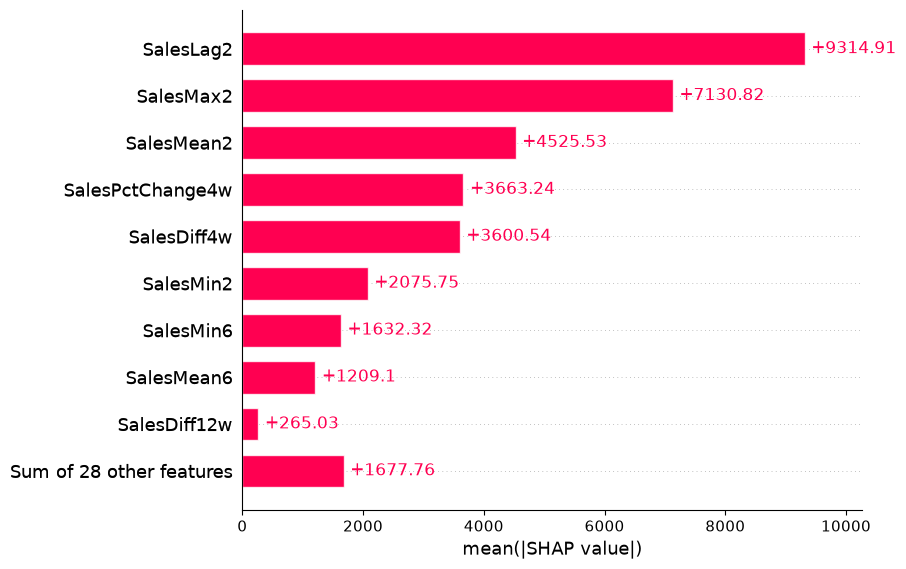

In [135]:
shap.plots.bar(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_bar.png')
plt.show()

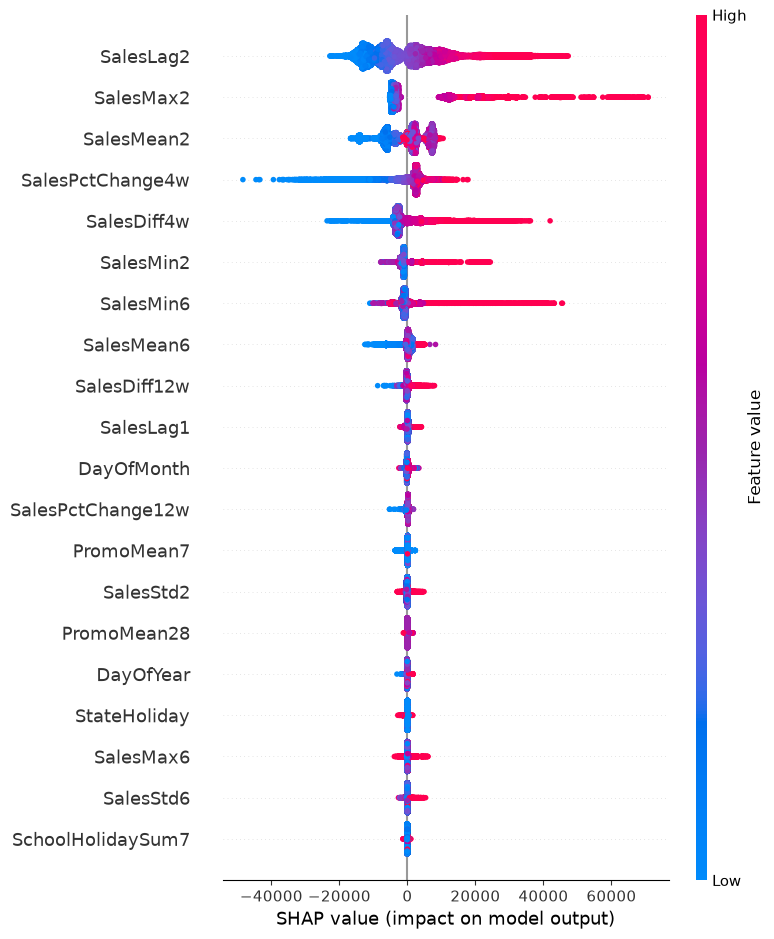

In [136]:
shap.summary_plot(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_summary.png')
plt.show()

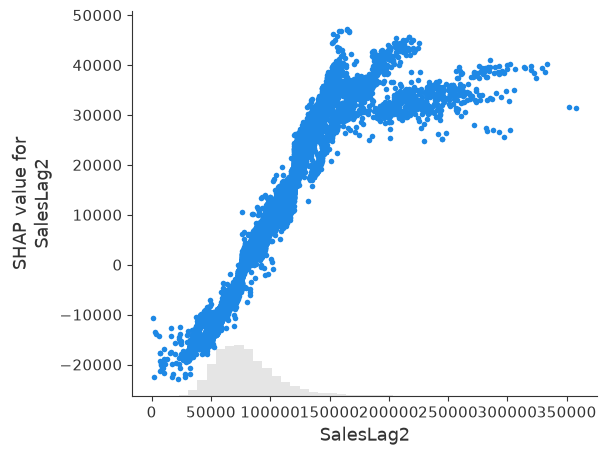

In [137]:
shap.plots.scatter(shap_values_cb[:, "SalesLag2"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_scatter_saleslag2.png')
plt.show()

In [138]:
mlflow.end_run()

🏃 View run cb_week2 at: http://localhost:5000/#/experiments/2/runs/f6dcd70b015241ec9b535a29919fd41b
🧪 View experiment at: http://localhost:5000/#/experiments/2


LightGBM

In [125]:
mlflow.start_run(run_id=lgbm_week2_run_id)

<ActiveRun: >

In [126]:
importance_df_lgbm_week2 = pd.DataFrame({
    'feature_name': lgbm_model_week2.feature_name_,
    'importance': lgbm_model_week2.feature_importances_ / np.sum(lgbm_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

mlflow.log_table(data=importance_df_lgbm_week2, artifact_file='feature_importance/lgbm_week2_top5.json')
importance_df_lgbm_week2

,feature_name,importance
0,Store,0.178554
1,SalesDiff4w,0.095278
2,SalesPctChange4w,0.087993
3,SalesLag2,0.071371
4,SalesStd2,0.065033


In [127]:
explainer = shap.TreeExplainer(lgbm_model_week2)
shap_values_lgbm = explainer(lgbm_train_week2)

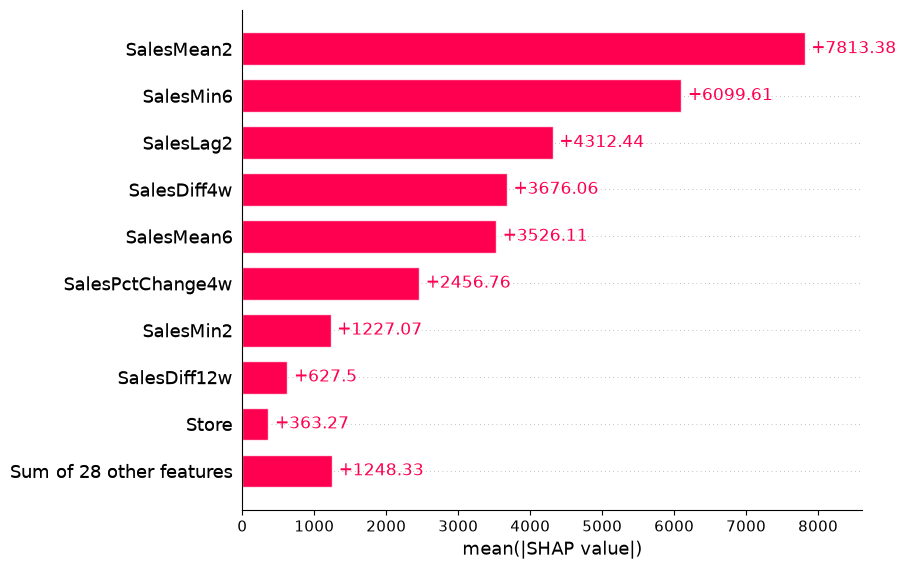

In [128]:
shap.plots.bar(shap_values_lgbm, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_bar.png')
plt.show()

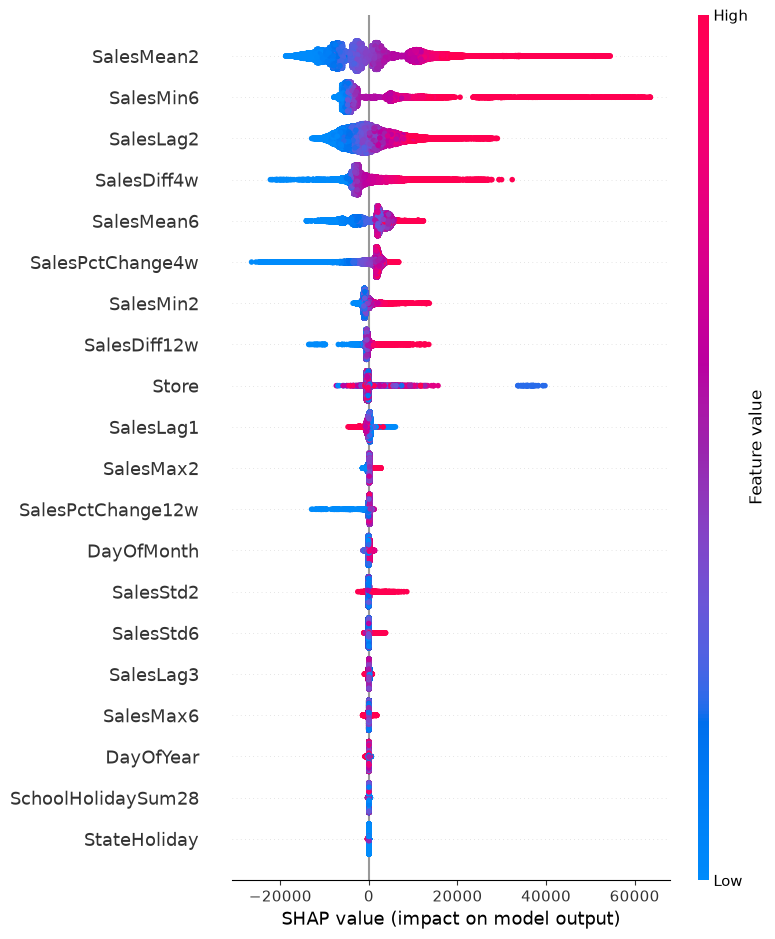

In [129]:
shap.summary_plot(shap_values_lgbm, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_summary.png')
plt.show()

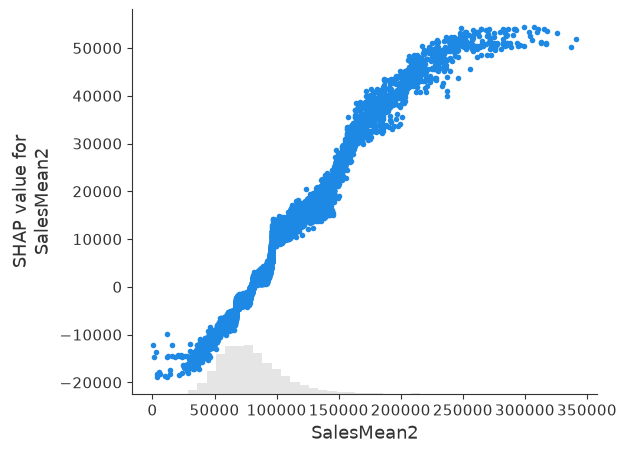

In [130]:
shap.plots.scatter(shap_values_lgbm[:, "SalesMean2"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_scatter_saleslag2.png')
plt.show()

In [131]:
mlflow.end_run()

🏃 View run lgbm_week2 at: http://localhost:5000/#/experiments/2/runs/5375abeaf087428499db03ba611bbd00
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [139]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [140]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Удаление выбросов

In [141]:
open_df = train_df[train_df['Open'] == 1]
q1 = open_df.groupby('Store')['Sales'].quantile(0.25)
q3 = open_df.groupby('Store')['Sales'].quantile(0.75)
iqr = q3 - q1

In [142]:
lower_bound = train_df['Store'].map(q1 - 1.5 * iqr)
upper_bound = train_df['Store'].map(q3 + 1.5 * iqr)
is_outlier = (train_df['Open'] == 1) & ((train_df['Sales'] < lower_bound) | (train_df['Sales'] > upper_bound))
print(f"В датасете всего {train_df[is_outlier].shape[0]} выбросов. Или в процентах: {train_df[is_outlier].shape[0]/train_df.shape[0]:.2%}")

В датасете всего 15285 выбросов. Или в процентах: 1.77%


In [143]:
train_df = train_df[~is_outlier]

# Пропуски в данных

In [144]:
missing = train_df.isna().sum()
missing[missing > 0]

CompetitionDistance      2189
CompetitionMonths      270396
PromoMean7               7697
PromoMean28             31059
SchoolHolidaySum7        7697
SchoolHolidaySum28      31059
dtype: int64

In [145]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [146]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

## IterativeImputer / SVR

In [147]:
svr_impute = IterativeImputer(estimator=SVR(max_iter=500, cache_size=1000), max_iter=5, random_state=42)
X_train_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

In [148]:
X_train_svr['CompetitionMonths'] = X_train_svr['CompetitionMonths'].astype(int)
X_train_svr['SchoolHolidaySum7'] = X_train_svr['SchoolHolidaySum7'].astype(int)
X_train_svr['SchoolHolidaySum28'] = X_train_svr['SchoolHolidaySum28'].astype(int)

X_val_svr['CompetitionMonths'] = X_val_svr['CompetitionMonths'].astype(int)
X_val_svr['SchoolHolidaySum7'] = X_val_svr['SchoolHolidaySum7'].astype(int)
X_val_svr['SchoolHolidaySum28'] = X_val_svr['SchoolHolidaySum28'].astype(int)

In [149]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [150]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [151]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9284917085964667
MSE score = 1115172.269662196
RMSE score = 1056.0171729958731
WAPE score = 11.167172406174036


Подготовка данных

In [152]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [153]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

In [154]:
with mlflow.start_run(run_name='preprocessing_no_outliers') as prep_run_no:
    mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
    mlflow.sklearn.log_model(svr_impute, 'imputer', serialization_format='pickle')
    mlflow.log_dict(
        {
            'cat_features': cat_features,
            'num_features': list(num_features),
            'target_columns': list(target_columns),
            'agg_dict': {k: (v if isinstance(v, str) else str(v)) for k, v in agg_dict.items()},
            'cutoff': str(cutoff),
        },
        'pipeline_metadata.json'
    )
    preprocessing_no_outliers_run_id = prep_run_no.info.run_id

2026/07/27 10:35:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 10:35:43 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 10:35:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/27 10:35:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/27 10:35:43 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 10:35:43 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run preprocessing_no_outliers at: http://localhost:5000/#/experiments/2/runs/d52c516264794fb5b8df573f2a680a2d
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Обучение

In [155]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

Предсказание по неделе вперед

In [156]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [157]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [158]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [159]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-27 10:35:51,869] A new study created in memory with name: no-name-ad71a175-b4cb-48ac-b86c-f3b63b70caca
[I 2026-07-27 10:36:50,442] Trial 0 finished with value: 1.128021938739387 and parameters: {'learning_rate': 0.16776008424305014, 'n_estimators': 439, 'min_child_samples': 233, 'num_leaves': 322, 'reg_lambda': 0.11580211104734242, 'colsample_bytree': 0.9926691850208786}. Best is trial 0 with value: 1.128021938739387.
[I 2026-07-27 10:38:05,193] Trial 1 finished with value: 3.7448476810962754 and parameters: {'learning_rate': 0.0023566696331619157, 'n_estimators': 940, 'min_child_samples': 104, 'num_leaves': 300, 'reg_lambda': 3.781726628988128, 'colsample_bytree': 0.7470070082945355}. Best is trial 0 with value: 1.128021938739387.
[I 2026-07-27 10:38:57,642] Trial 2 finished with value: 1.1677698841141582 and parameters: {'learning_rate': 0.025425500631671743, 'n_estimators': 431, 'min_child_samples': 320, 'num_leaves': 317, 'reg_lambda': 0.06309466936680454, 'colsample_byt

In [160]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [161]:
with mlflow.start_run(run_name='lgbm_week1 no_outliers') as run:
    mlflow.log_params(study_lgbm_week1.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week1)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week1, 'model')
    lgbm_week1_no_run_id = run.info.run_id

2026/07/27 10:52:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 10:52:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 10:52:22 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 10:52:22 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 10:52:23 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 10:52:23 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 10:52:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week1 no_outliers at: http://localhost:5000/#/experiments/2/runs/ed939ea7e68a4ad7ab10f69b08273c4e
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [162]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-27 10:52:24,303] A new study created in memory with name: no-name-cefb3baa-9389-4c07-86bb-92c6e7cf3792
[I 2026-07-27 10:56:09,629] Trial 0 finished with value: 13.161312131666806 and parameters: {'learning_rate': 0.0010955266538182076, 'iterations': 1033, 'depth': 8, 'bagging_temperature': 8.049224968033615, 'l2_leaf_reg': 9.364922663070116, 'random_strength': 3.7903060657731125, 'subsample': 0.5114315134112667}. Best is trial 0 with value: 13.161312131666806.
[I 2026-07-27 10:58:57,887] Trial 1 finished with value: 8.475307301261081 and parameters: {'learning_rate': 0.0019158382107272959, 'iterations': 917, 'depth': 6, 'bagging_temperature': 6.5981445286258245, 'l2_leaf_reg': 9.974298082082267, 'random_strength': 4.869552396674126, 'subsample': 0.9547263901008959}. Best is trial 1 with value: 8.475307301261081.
[I 2026-07-27 11:00:29,707] Trial 2 finished with value: 0.7064720637428683 and parameters: {'learning_rate': 0.5151005270412269, 'iterations': 574, 'depth': 4, 'bag

In [163]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [164]:
with mlflow.start_run(run_name='cb_week1 no_outliers') as run:
    mlflow.log_params(study_cb_week1.best_params)
    mlflow.log_metric('WAPE', score_cb_week1)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week1, 'model')
    cb_week1_no_run_id = run.info.run_id

2026/07/27 11:33:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 11:33:40 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 11:33:40 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 11:33:40 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 11:33:40 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 11:33:40 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 11:33:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week1 no_outliers at: http://localhost:5000/#/experiments/2/runs/3bb70c96ec8648f39242b2b3cedea69f
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 2 недели

In [165]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [166]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [167]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [168]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-27 11:33:46,771] A new study created in memory with name: no-name-0b11c68e-d7a0-4796-a8f3-3e1b829534dc
[I 2026-07-27 11:34:17,001] Trial 0 finished with value: 0.7862578631077191 and parameters: {'learning_rate': 0.09085956909408076, 'n_estimators': 911, 'min_child_samples': 262, 'num_leaves': 385, 'reg_lambda': 0.02246902491016733, 'colsample_bytree': 0.5761454130153862}. Best is trial 0 with value: 0.7862578631077191.
[I 2026-07-27 11:34:58,947] Trial 1 finished with value: 1.581656418087162 and parameters: {'learning_rate': 0.6050090124944909, 'n_estimators': 1032, 'min_child_samples': 81, 'num_leaves': 344, 'reg_lambda': 0.06874262453103744, 'colsample_bytree': 0.5691833808664715}. Best is trial 0 with value: 0.7862578631077191.
[I 2026-07-27 11:35:25,475] Trial 2 finished with value: 0.8778989090257493 and parameters: {'learning_rate': 0.012563674090165067, 'n_estimators': 396, 'min_child_samples': 69, 'num_leaves': 322, 'reg_lambda': 4.910192078545693, 'colsample_bytre

In [169]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [170]:
with mlflow.start_run(run_name='lgbm_week2 no_outliers') as run:
    mlflow.log_params(study_lgbm_week2.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week2)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week2, 'model')
    lgbm_week2_no_run_id = run.info.run_id

2026/07/27 11:43:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 11:43:32 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 11:43:33 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 11:43:33 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 11:43:33 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 11:43:33 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 11:43:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week2 no_outliers at: http://localhost:5000/#/experiments/2/runs/38203c82843e4b0ea27c2a9eae9594c7
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [171]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-27 11:43:35,225] A new study created in memory with name: no-name-1fa9c38a-fd3d-4a52-801c-edb1d32681e3
[I 2026-07-27 11:47:13,587] Trial 0 finished with value: 0.7332885228965168 and parameters: {'learning_rate': 0.3241460231495956, 'iterations': 763, 'depth': 10, 'bagging_temperature': 0.4008861633456451, 'l2_leaf_reg': 4.827540644667538, 'random_strength': 1.6580504509772587, 'subsample': 0.9649897520838703}. Best is trial 0 with value: 0.7332885228965168.
[I 2026-07-27 11:48:59,157] Trial 1 finished with value: 1.7309721419967228 and parameters: {'learning_rate': 0.007198304552346256, 'iterations': 847, 'depth': 6, 'bagging_temperature': 8.599326837400593, 'l2_leaf_reg': 7.490270500918951, 'random_strength': 9.204806560247285, 'subsample': 0.5835553145156258}. Best is trial 0 with value: 0.7332885228965168.
[I 2026-07-27 11:50:32,039] Trial 2 finished with value: 10.498469938646277 and parameters: {'learning_rate': 0.0019573939087004152, 'iterations': 695, 'depth': 6, 'ba

In [172]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [173]:
with mlflow.start_run(run_name='cb_week2 no_outliers') as run:
    mlflow.log_params(study_cb_week2.best_params)
    mlflow.log_metric('WAPE', score_cb_week2)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week2, 'model')
    cb_week2_no_run_id = run.info.run_id

2026/07/27 12:22:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 12:22:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:22:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:22:28 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 12:22:28 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 12:22:28 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 12:22:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week2 no_outliers at: http://localhost:5000/#/experiments/2/runs/c371eb95af764d58a630cd9d8ad99e55
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 4 недели


In [174]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [175]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [176]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [177]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-27 12:22:40,637] A new study created in memory with name: no-name-6cb866c2-6ea0-498c-8d6a-eacbed42c952
[I 2026-07-27 12:22:57,587] Trial 0 finished with value: 1.1566887068914726 and parameters: {'learning_rate': 0.1142036694354917, 'n_estimators': 1130, 'min_child_samples': 385, 'num_leaves': 341, 'reg_lambda': 0.05205542146493857, 'colsample_bytree': 0.9180504759644963}. Best is trial 0 with value: 1.1566887068914726.
[I 2026-07-27 12:23:13,399] Trial 1 finished with value: 1.1837037492284808 and parameters: {'learning_rate': 0.3338060327540413, 'n_estimators': 623, 'min_child_samples': 131, 'num_leaves': 372, 'reg_lambda': 0.022375801621031526, 'colsample_bytree': 0.6590727810941948}. Best is trial 0 with value: 1.1566887068914726.
[I 2026-07-27 12:23:31,235] Trial 2 finished with value: 0.9485824140010854 and parameters: {'learning_rate': 0.009047459612515874, 'n_estimators': 1155, 'min_child_samples': 188, 'num_leaves': 307, 'reg_lambda': 0.016622528323147163, 'colsampl

In [178]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [179]:
with mlflow.start_run(run_name='lgbm_week4 no_outliers') as run:
    mlflow.log_params(study_lgbm_week4.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week4)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week4, 'model')
    lgbm_week4_no_run_id = run.info.run_id

2026/07/27 12:27:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 12:27:42 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:27:42 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:27:42 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 12:27:43 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 12:27:43 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 12:27:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week4 no_outliers at: http://localhost:5000/#/experiments/2/runs/af7a182038ea4aa7bb0e2f66fbe979a5
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [180]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-27 12:27:44,115] A new study created in memory with name: no-name-4f3c5e7d-8cfa-4e48-aa40-606f03f8444b
[I 2026-07-27 12:29:05,594] Trial 0 finished with value: 9.735674345469704 and parameters: {'learning_rate': 0.0018001345143222717, 'iterations': 698, 'depth': 7, 'bagging_temperature': 5.522592892280535, 'l2_leaf_reg': 8.00358843157186, 'random_strength': 1.8729189621196607, 'subsample': 0.6525304525454803}. Best is trial 0 with value: 9.735674345469704.
[I 2026-07-27 12:30:59,279] Trial 1 finished with value: 1.5740040283535934 and parameters: {'learning_rate': 0.0071054954506266635, 'iterations': 920, 'depth': 7, 'bagging_temperature': 7.271206930657841, 'l2_leaf_reg': 7.2667816027315775, 'random_strength': 2.4604777706986214, 'subsample': 0.9904618112877352}. Best is trial 1 with value: 1.5740040283535934.
[I 2026-07-27 12:31:41,230] Trial 2 finished with value: 11.940693777110726 and parameters: {'learning_rate': 0.0031245241209790124, 'iterations': 327, 'depth': 6, 'b

In [181]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [182]:
with mlflow.start_run(run_name='cb_week4 no_outliers') as run:
    mlflow.log_params(study_cb_week4.best_params)
    mlflow.log_metric('WAPE', score_cb_week4)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week4, 'model')
    cb_week4_no_run_id = run.info.run_id

2026/07/27 12:49:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 12:49:16 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:49:16 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:49:16 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 12:49:16 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 12:49:16 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 12:49:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week4 no_outliers at: http://localhost:5000/#/experiments/2/runs/ebdffe02512d480aa744a42c1921a9d1
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 6 недель

In [183]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [184]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [185]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [186]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-27 12:49:23,298] A new study created in memory with name: no-name-787bb261-e497-4936-9ab9-225cbf6b1c67
[I 2026-07-27 12:49:31,313] Trial 0 finished with value: 2.579824257605533 and parameters: {'learning_rate': 0.26139736129299557, 'n_estimators': 617, 'min_child_samples': 461, 'num_leaves': 333, 'reg_lambda': 0.11894019517401347, 'colsample_bytree': 0.682102087271986}. Best is trial 0 with value: 2.579824257605533.
[I 2026-07-27 12:49:38,945] Trial 1 finished with value: 2.8268954678720326 and parameters: {'learning_rate': 0.022994262513347467, 'n_estimators': 617, 'min_child_samples': 451, 'num_leaves': 363, 'reg_lambda': 1.4336054431513818, 'colsample_bytree': 0.7515130991178286}. Best is trial 0 with value: 2.579824257605533.
[I 2026-07-27 12:49:46,523] Trial 2 finished with value: 2.6514609091127324 and parameters: {'learning_rate': 0.012213441934311182, 'n_estimators': 383, 'min_child_samples': 385, 'num_leaves': 306, 'reg_lambda': 0.013435844778881413, 'colsample_byt

In [187]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [188]:
with mlflow.start_run(run_name='lgbm_week6 no_outliers') as run:
    mlflow.log_params(study_lgbm_week6.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week6)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week6, 'model')
    lgbm_week6_no_run_id = run.info.run_id

2026/07/27 12:52:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 12:52:00 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:52:01 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 12:52:01 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 12:52:01 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 12:52:01 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 12:52:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week6 no_outliers at: http://localhost:5000/#/experiments/2/runs/5a5eb7f99fb94f06aa241e012dc69bd8
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [189]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-27 12:52:02,869] A new study created in memory with name: no-name-4e75db85-56f8-4dc8-820f-415161633424
[I 2026-07-27 12:53:29,656] Trial 0 finished with value: 7.040954762979462 and parameters: {'learning_rate': 0.0028354005451366833, 'iterations': 537, 'depth': 9, 'bagging_temperature': 2.919417933860574, 'l2_leaf_reg': 5.035527278485669, 'random_strength': 0.6163107173152316, 'subsample': 0.5560452777746236}. Best is trial 0 with value: 7.040954762979462.
[I 2026-07-27 12:55:13,576] Trial 1 finished with value: 3.7651418881895706 and parameters: {'learning_rate': 0.003972761019098484, 'iterations': 752, 'depth': 9, 'bagging_temperature': 3.964898318891522, 'l2_leaf_reg': 6.300732952016579, 'random_strength': 9.81744820140889, 'subsample': 0.9458123271446585}. Best is trial 1 with value: 3.7651418881895706.
[I 2026-07-27 12:58:35,045] Trial 2 finished with value: 0.8229244166085801 and parameters: {'learning_rate': 0.3125924336626261, 'iterations': 1033, 'depth': 8, 'baggin

In [190]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [191]:
with mlflow.start_run(run_name='cb_week6 no_outliers') as run:
    mlflow.log_params(study_cb_week6.best_params)
    mlflow.log_metric('WAPE', score_cb_week6)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week6, 'model')
    cb_week6_no_run_id = run.info.run_id

2026/07/27 13:27:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 13:27:30 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 13:27:30 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 13:27:30 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 13:27:30 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 13:27:30 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 13:27:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week6 no_outliers at: http://localhost:5000/#/experiments/2/runs/b4a5b3a5bcf049ddbeecbc346f8d4f30
🧪 View experiment at: http://localhost:5000/#/experiments/2


Предсказание по группировке 12 недель

In [192]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [193]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [194]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [195]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-27 13:27:37,867] A new study created in memory with name: no-name-704d7aac-a71f-4977-aa3e-1e89c7477eae
[I 2026-07-27 13:27:42,095] Trial 0 finished with value: 6.7771435221972745 and parameters: {'learning_rate': 0.029649967015066805, 'n_estimators': 716, 'min_child_samples': 265, 'num_leaves': 361, 'reg_lambda': 8.157539204127195, 'colsample_bytree': 0.7285837140315898}. Best is trial 0 with value: 6.7771435221972745.
[I 2026-07-27 13:27:46,074] Trial 1 finished with value: 7.118916637118109 and parameters: {'learning_rate': 0.07189839648339613, 'n_estimators': 1013, 'min_child_samples': 299, 'num_leaves': 367, 'reg_lambda': 3.1955495116006594, 'colsample_bytree': 0.9683594810978862}. Best is trial 0 with value: 6.7771435221972745.
[I 2026-07-27 13:27:50,220] Trial 2 finished with value: 4.853862296602148 and parameters: {'learning_rate': 0.05551326425556516, 'n_estimators': 636, 'min_child_samples': 141, 'num_leaves': 397, 'reg_lambda': 0.5382368817517301, 'colsample_bytre

In [196]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [197]:
with mlflow.start_run(run_name='lgbm_week12 no_outliers') as run:
    mlflow.log_params(study_lgbm_week12.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week12)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week12, 'model')
    lgbm_week12_no_run_id = run.info.run_id

2026/07/27 13:28:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 13:28:45 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 13:28:45 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 13:28:45 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 13:28:46 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 13:28:46 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 13:28:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week12 no_outliers at: http://localhost:5000/#/experiments/2/runs/809c7382c74944279677c181474cfc76
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [198]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-27 13:28:47,285] A new study created in memory with name: no-name-c8d83ce9-2c80-4ff7-9c9f-6853f8456104
[I 2026-07-27 13:31:01,152] Trial 0 finished with value: 2.6771152109977856 and parameters: {'learning_rate': 0.450312374889981, 'iterations': 713, 'depth': 9, 'bagging_temperature': 7.431667553936241, 'l2_leaf_reg': 4.047917822886373, 'random_strength': 7.806609506618804, 'subsample': 0.8617850742187686}. Best is trial 0 with value: 2.6771152109977856.
[I 2026-07-27 13:32:56,642] Trial 1 finished with value: 6.031903835820886 and parameters: {'learning_rate': 0.0022172312491981843, 'iterations': 1066, 'depth': 6, 'bagging_temperature': 7.653100675499812, 'l2_leaf_reg': 9.806431583112577, 'random_strength': 4.194297622606595, 'subsample': 0.8233601028386982}. Best is trial 0 with value: 2.6771152109977856.
[I 2026-07-27 13:34:12,785] Trial 2 finished with value: 3.046002061284254 and parameters: {'learning_rate': 0.945275596896521, 'iterations': 530, 'depth': 5, 'bagging_te

In [199]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [200]:
with mlflow.start_run(run_name='cb_week12 no_outliers') as run:
    mlflow.log_params(study_cb_week12.best_params)
    mlflow.log_metric('WAPE', score_cb_week12)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week12, 'model')
    cb_week12_no_run_id = run.info.run_id

2026/07/27 13:57:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 13:57:01 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 13:57:01 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/27 13:57:01 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/27 13:57:01 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/27 13:57:01 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/27 13:57:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week12 no_outliers at: http://localhost:5000/#/experiments/2/runs/074c994e9d134137a8d62165c195c770
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Сравнение качества

In [201]:
comparison_no_outliers = pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

comparison_no_outliers

,WAPE score
CatBoost week2,0.508319
CatBoost week1,0.595293
CatBoost week4,0.609238
LGBM week6,0.621146
CatBoost week6,0.703128
LGBM week2,0.704836
LGBM week4,0.791728
LGBM week1,0.876977
CatBoost week12,1.091370
LGBM week12,2.808091


In [202]:
with mlflow.start_run(run_name='comparison_no_outliers'):
    mlflow.log_table(data=comparison_no_outliers.reset_index(), artifact_file='comparison/no_outliers_wape.json')

🏃 View run comparison_no_outliers at: http://localhost:5000/#/experiments/2/runs/e009e74fa5f649fc8f774356f97dc8cf
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Feature Importance

CatBoost

In [203]:
mlflow.start_run(run_id=cb_week2_no_run_id)

<ActiveRun: >

In [204]:
importance_df_cb_week2_no = pd.DataFrame({
    'feature_name': cb_model_week2.feature_names_,
    'importance': cb_model_week2.feature_importances_ / np.sum(cb_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

importance_df_cb_week2_no

,feature_name,importance
0,SalesMean6,0.485462
1,SalesLag2,0.129644
2,SalesMean2,0.127146
3,SalesMin6,0.064708
4,SalesDiff4w,0.056733


In [205]:
mlflow.log_table(data=importance_df_cb_week2_no, artifact_file='feature_importance/cb_week2_no_outliers_top5.json')

In [206]:
explainer_cb = shap.TreeExplainer(cb_model_week2)
shap_values_cb = explainer_cb(cb_train_week2)

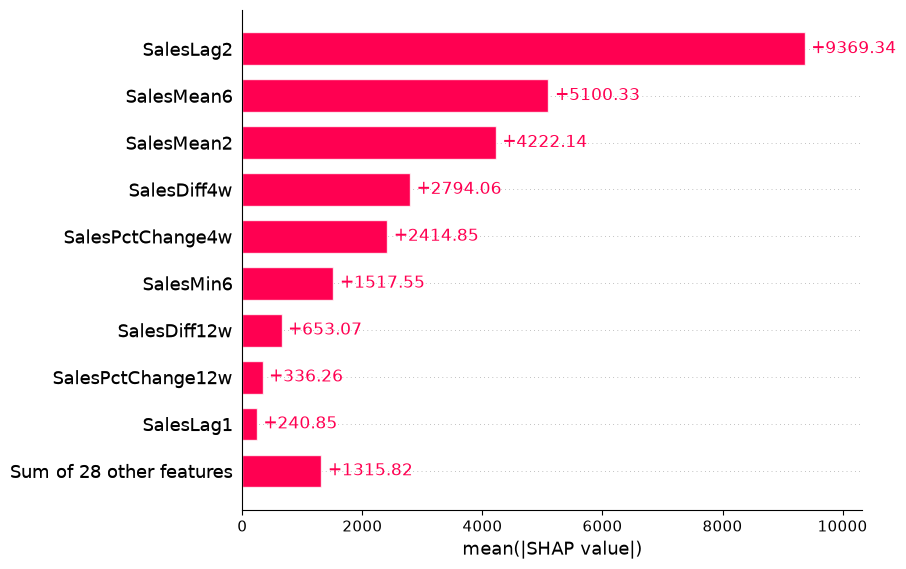

In [207]:
shap.plots.bar(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_no_outliers_bar.png')
plt.show()

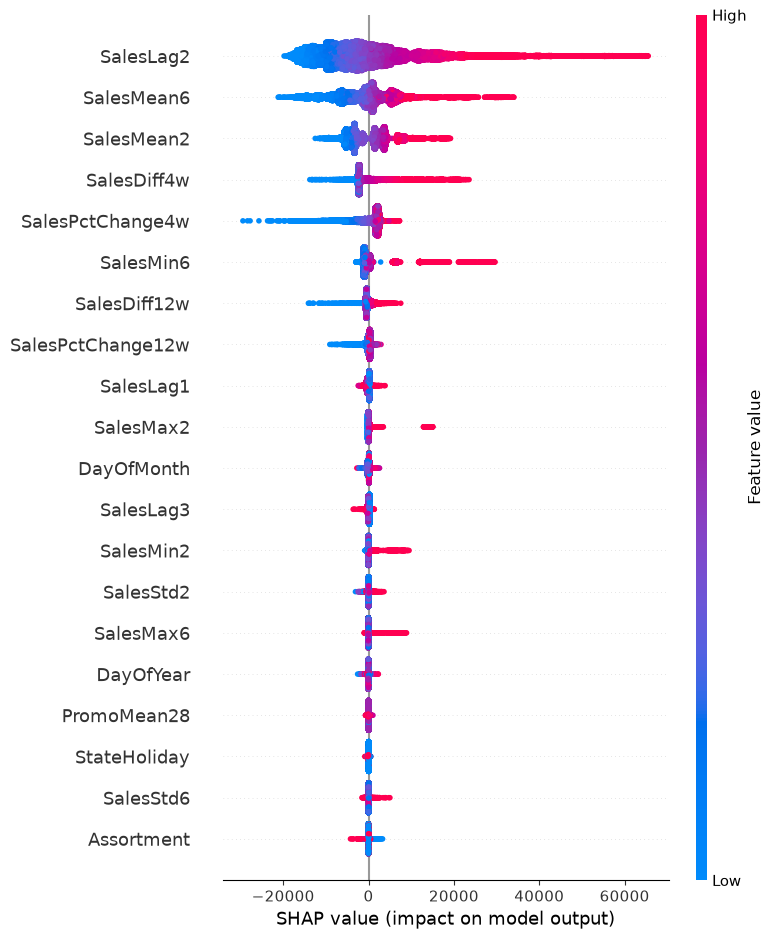

In [208]:
shap.summary_plot(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_no_outliers_summary.png')
plt.show()

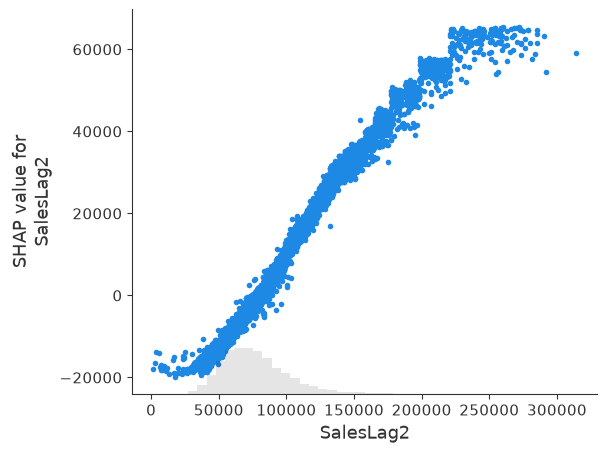

In [209]:
shap.plots.scatter(shap_values_cb[:, "SalesLag2"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_no_outliers_scatter_saleslag2.png')
plt.show()

In [210]:
mlflow.end_run()

🏃 View run cb_week2 no_outliers at: http://localhost:5000/#/experiments/2/runs/c371eb95af764d58a630cd9d8ad99e55
🧪 View experiment at: http://localhost:5000/#/experiments/2


LightGBM

In [211]:
mlflow.start_run(run_id=lgbm_week6_no_run_id)

<ActiveRun: >

In [212]:
importance_df_lgbm_week6_no = pd.DataFrame({
    'feature_name': lgbm_model_week6.feature_name_,
    'importance': lgbm_model_week6.feature_importances_ / np.sum(lgbm_model_week6.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

importance_df_lgbm_week6_no

,feature_name,importance
0,SalesDiff12w,0.077537
1,SalesPctChange6w,0.076210
2,SalesDiff6w,0.074207
3,SalesStd4,0.073706
4,SalesPctChange12w,0.072853


In [213]:
mlflow.log_table(data=importance_df_lgbm_week6_no, artifact_file='feature_importance/lgbm_week6_no_outliers_top5.json')

In [214]:
explainer = shap.TreeExplainer(lgbm_model_week6)
shap_values_lgbm = explainer(lgbm_train_week6)

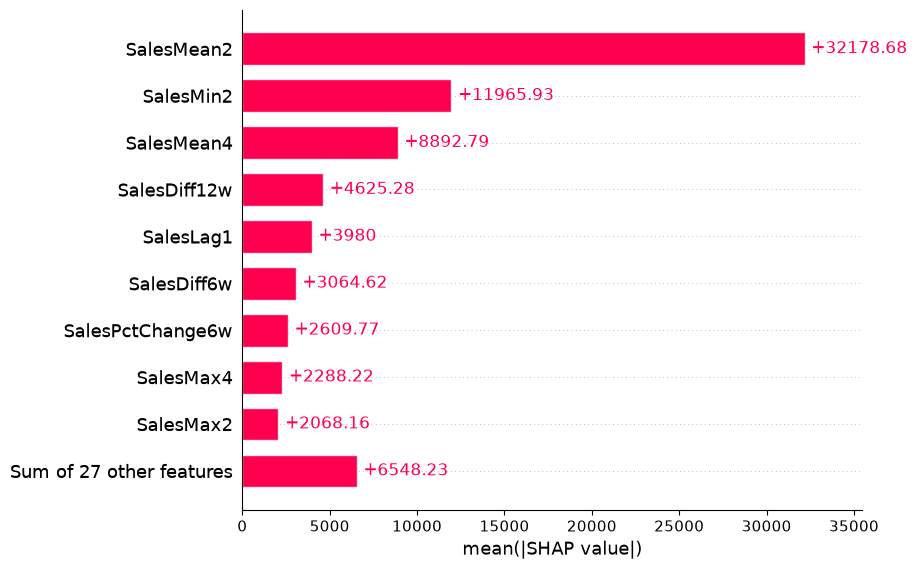

In [215]:
shap.plots.bar(shap_values_lgbm, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week6_no_outliers_bar.png')
plt.show()

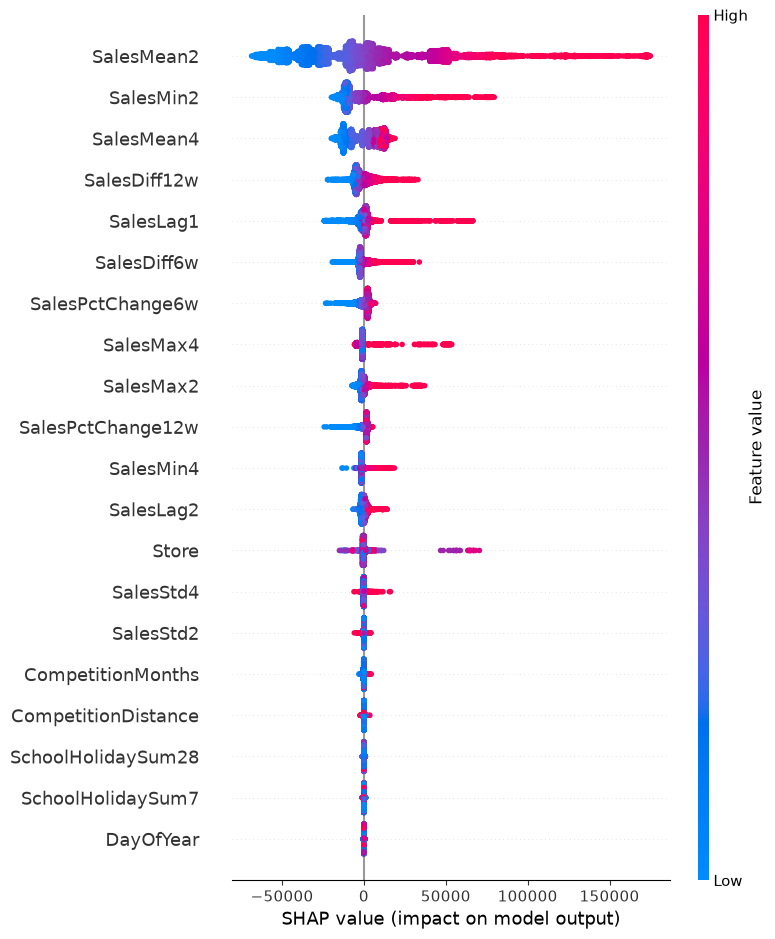

In [216]:
shap.summary_plot(shap_values_lgbm, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week6_no_outliers_summary.png')
plt.show()

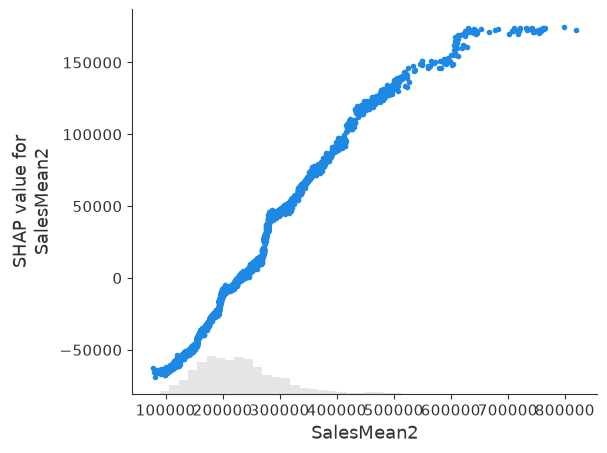

In [217]:
shap.plots.scatter(shap_values_lgbm[:, "SalesMean2"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week6_no_outliers_scatter_salesmean2.png')
plt.show()

In [218]:
mlflow.end_run()

🏃 View run lgbm_week6 no_outliers at: http://localhost:5000/#/experiments/2/runs/5a5eb7f99fb94f06aa241e012dc69bd8
🧪 View experiment at: http://localhost:5000/#/experiments/2
